<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">📉 Gradiente Descendiente en Machine Learning</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 3 — El algoritmo de optimización detrás del entrenamiento de un modelo</p>
</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:0 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#importacion">Importación de librerías</a></li>
<li><a href="#funcion-costo">Definición de la función de costo</a></li>
<li><a href="#gradiente">Definición de la derivada (gradiente)</a></li>
<li><a href="#ejecucion">Parámetros y ejecución del descenso del gradiente</a></li>
<li><a href="#graficar">Graficar el descenso del gradiente</a></li>
<li><a href="#minimos">Mínimos locales y globales</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="introduccion"></a>

El **gradiente descendiente** es un método de optimización que básicamente consiste en *"bajar la colina"* de una función hasta encontrar su punto más bajo, que representa la mejor solución posible.

En **inteligencia artificial y machine learning** se usa para entrenar modelos ajustando sus parámetros *(pesos)* de forma iterativa: se calcula la pendiente de la función de error y se actualizan los valores en la dirección contraria al gradiente, con pasos controlados por la tasa de aprendizaje.

En pocas palabras, es el **GPS matemático** que guía al modelo desde el caos inicial hacia un conjunto de parámetros que minimizan los errores y permiten hacer predicciones más precisas.

<a id="importacion"></a>

## <span style="color:#F97066;">1.</span> Importación de librerías

In [2]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt 

<a id="funcion-costo"></a>

## <span style="color:#F97066;">2.</span> Definición de la función de costo

Una **función de costo** (o función de pérdida) mide qué tan lejos están las predicciones de un modelo respecto a los valores reales; entrenar un modelo consiste, precisamente, en encontrar los parámetros que minimizan esta función. A modo de ejemplo didáctico, se utilizará una función de costo simple de una sola variable, $J(\theta) = \theta^2 + 3\theta + 2$, cuyo mínimo puede calcularse analíticamente pero servirá para ilustrar el algoritmo paso a paso.

In [5]:
# Definir la función de costo J(theta) = theta^2 + 3theta + 2
def costo(theta):
    return theta**2 + 3 * theta + 2 

<a id="gradiente"></a>

## <span style="color:#F97066;">3.</span> Definición de la derivada (gradiente)

El **gradiente** de una función es su derivada: indica la dirección en la que la función crece más rápido. Por esta razón, para *minimizar* la función de costo, el algoritmo se mueve en la dirección **contraria** al gradiente (de ahí el nombre "descendiente"). Para la función de costo definida arriba, la derivada es $\frac{dJ}{d\theta} = 2\theta + 3$.

In [4]:
# Definir la derivada de la función de costo (gradiente) 
# dJ/d(theta) = 2 * theta + 3 
def gradiente(theta):
    return 2 * theta + 3

<a id="ejecucion"></a>

## <span style="color:#F97066;">4.</span> Parámetros y ejecución del descenso del gradiente

La regla de actualización del algoritmo es $\theta_{nuevo} = \theta_{actual} - \alpha \cdot \nabla J(\theta)$, donde $\alpha$ (**alpha**) es la **tasa de aprendizaje** (*learning rate*): un valor que controla qué tan grande es cada paso hacia el mínimo. `theta` se inicializa en un valor arbitrario (aquí, 5) y se actualiza durante un número fijo de iteraciones.

In [6]:
# Parámetros del descenso del gradiente
alpha = 0.1  # Tasa de aprendizaje
theta = 5  # Valor inicial
num_iter = 20  # Número de iteraciones

# Almacenar valores para visualizar el descenso
historial_theta = [theta]
historial_costo = [costo(theta)]

# Aplicar Descenso del Gradiente
for i in range(num_iter):
    theta = theta - alpha * gradiente(theta)  # Actualizar el parámetro
    historial_theta.append(theta)
    historial_costo.append(costo(theta))

### Efecto de la tasa de aprendizaje

La elección de $\alpha$ es crítica para que el algoritmo converja correctamente:

- **Muy pequeña**: el algoritmo converge, pero de forma muy lenta (requiere muchas más iteraciones).
- **Adecuada**: converge de forma rápida y estable hacia el mínimo.
- **Muy grande**: el algoritmo puede oscilar sin control y **divergir** (alejarse cada vez más del mínimo, en lugar de acercarse).

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda y observe el valor final de `theta` para tres tasas de aprendizaje distintas. El mínimo real de esta función se encuentra en $\theta = -1.5$.

In [7]:
# Se compara el efecto de distintas tasas de aprendizaje sobre la convergencia
tasas_aprendizaje = [0.01, 0.1, 1.05]

for alpha_prueba in tasas_aprendizaje:
    theta_prueba = 5
    for _ in range(20):
        theta_prueba = theta_prueba - alpha_prueba * gradiente(theta_prueba)
    print(f"alpha = {alpha_prueba:<5} -> theta final = {theta_prueba:10.4f}, costo final = {costo(theta_prueba):10.4f}")

alpha = 0.01  -> theta final =     2.8395, costo final =    18.5808
alpha = 0.1   -> theta final =    -1.4251, costo final =    -0.2444
alpha = 1.05  -> theta final =    42.2287, costo final =  1911.9535


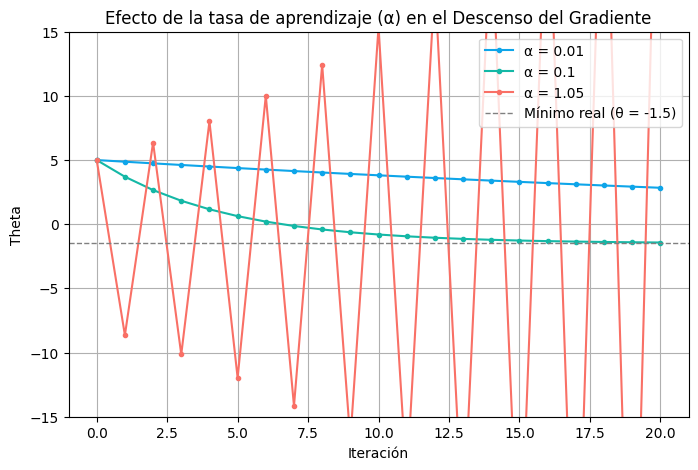

In [8]:
# Se grafica la trayectoria de theta para cada tasa de aprendizaje
alphas = [0.01, 0.1, 1.05]
colores = ["#0EA5E9", "#14B8A6", "#F97066"]

plt.figure(figsize=(8, 5))
for alpha_i, color in zip(alphas, colores):
    theta_i = 5
    historial = [theta_i]
    for _ in range(20):
        theta_i = theta_i - alpha_i * gradiente(theta_i)
        historial.append(theta_i)
    plt.plot(range(len(historial)), historial, marker="o", markersize=3, color=color, label=f"α = {alpha_i}")

plt.axhline(-1.5, color="gray", linestyle="dashed", linewidth=1, label="Mínimo real (θ = -1.5)")
plt.xlabel("Iteración")
plt.ylabel("Theta")
plt.title("Efecto de la tasa de aprendizaje (α) en el Descenso del Gradiente")
plt.legend()
plt.grid(True)
plt.ylim(-15, 15)
plt.show()

<a id="graficar"></a>

## <span style="color:#F97066;">5.</span> Graficar el descenso del gradiente

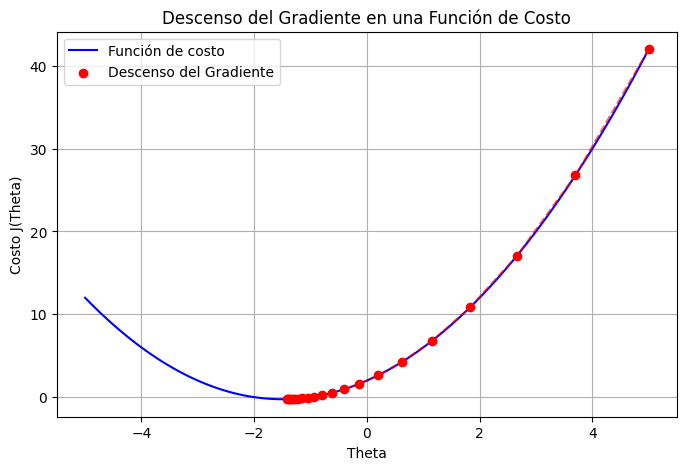

In [7]:
# Graficar la función de costo y el descenso del gradiente
theta_vals = np.linspace(-5, 5, 100)
costo_vals = costo(theta_vals)

plt.figure(figsize=(8, 5))
plt.plot(theta_vals, costo_vals, label="Función de costo", color="blue")
plt.scatter(
    historial_theta,
    historial_costo,
    color="red",
    label="Descenso del Gradiente",
    zorder=3,
)

plt.plot(
    historial_theta, historial_costo, color="red", linestyle="dashed", alpha=0.6
)  # Línea del descenso
plt.xlabel("Theta")
plt.ylabel("Costo J(Theta)")
plt.title("Descenso del Gradiente en una Función de Costo")
plt.legend()
plt.grid(True)
plt.show()

<a id="minimos"></a>

## <span style="color:#F97066;">6.</span> Mínimos locales y globales

Un **mínimo local** es como caer en un valle pequeño dentro de una montaña: desde ese punto todo alrededor parece más alto, pero no necesariamente es el punto más bajo de todo el terreno.

El **mínimo global**, en cambio, es el valle más profundo de todo el paisaje, el lugar donde realmente termina la bajada.

En **machine learning**, el gradiente descendiente puede quedarse atrapado en *mínimos locales*, lo que significa que el modelo encuentra una solución *"aceptable"* pero no necesariamente la mejor.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
La superficie siguiente se grafica con <strong>Plotly</strong> en lugar de matplotlib: a diferencia de un gráfico 3D de matplotlib (estático por defecto) o de seaborn (que no incluye soporte para gráficos 3D), Plotly genera una figura verdaderamente interactiva. Puede hacer clic y arrastrar para rotarla, desplazarse para hacer zoom, y pasar el cursor sobre cualquier punto para ver sus coordenadas exactas, directamente sobre la salida guardada del notebook.
</div>

In [ ]:
import numpy as np
import plotly.graph_objects as go

# Definimos la función con múltiples mínimos locales
def f(x, y):
    return np.sin(x) * np.cos(y) + 0.1*(x**2 + y**2)

# Gradiente de la función
def grad_f(x, y):
    df_dx = np.cos(x) * np.cos(y) + 0.2 * x
    df_dy = -np.sin(x) * np.sin(y) + 0.2 * y
    return np.array([df_dx, df_dy])

# Simulación de gradiente descendiente
def gradient_descent(start, lr=0.05, steps=50):
    path = [start]
    point = np.array(start, dtype=float)
    for _ in range(steps):
        grad = grad_f(point[0], point[1])
        point = point - lr * grad
        path.append(point.copy())
    return np.array(path)

# Crear la malla para graficar la superficie
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# Ejecutar gradiente descendiente desde un punto inicial
start = [4, 4]
path = gradient_descent(start, lr=0.1, steps=40)
z_path = f(path[:, 0], path[:, 1])

# Superficie interactiva: se puede rotar, hacer zoom y pasar el cursor sobre los puntos
fig = go.Figure()

fig.add_trace(go.Surface(x=X, y=Y, z=Z, colorscale="Viridis", opacity=0.75, showscale=False))

fig.add_trace(go.Scatter3d(
    x=path[:, 0], y=path[:, 1], z=z_path,
    mode="lines+markers",
    line=dict(color="#F97066", width=4),
    marker=dict(size=4, color="#F97066"),
    name="Descenso"
))

fig.add_trace(go.Scatter3d(
    x=[start[0]], y=[start[1]], z=[f(start[0], start[1])],
    mode="markers", marker=dict(size=6, color="#0EA5E9"), name="Inicio"
))

fig.add_trace(go.Scatter3d(
    x=[path[-1, 0]], y=[path[-1, 1]], z=[z_path[-1]],
    mode="markers", marker=dict(size=6, color="black"), name="Final"
))

fig.update_layout(
    title="Gradiente Descendiente con Mínimos Locales (interactivo)",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="f(x, y)"),
    width=800, height=600,
    margin=dict(l=0, r=0, b=0, t=40),
)

fig.show()

### Criterio de convergencia: la norma del gradiente

En el ejemplo anterior, el descenso se ejecutó un número fijo de pasos (40), sin verificar si ya se había alcanzado un mínimo. En la práctica, es más eficiente detener el algoritmo cuando el gradiente sea suficientemente pequeño, es decir, cuando su **norma** —el mismo concepto de magnitud de un vector presentado en el notebook anterior (`1-algebra-lineal-ML.ipynb`)— caiga por debajo de un umbral de tolerancia. Esto evita seguir iterando innecesariamente una vez que el algoritmo ya se encuentra muy cerca de un mínimo (local o global).

<span style="background:#0EA5E9;color:#ffffff;padding:4px 14px;border-radius:14px;font-size:0.75em;">🧪 EJERCICIO</span>

Ejecute la siguiente celda: el algoritmo se detendrá automáticamente en cuanto la norma del gradiente sea menor a `1e-4`, en lugar de completar siempre 40 pasos.

In [16]:
def gradiente_descendiente_con_tolerancia(start, lr=0.1, tolerancia=1e-4, max_pasos=200):
    punto = np.array(start, dtype=float)
    for paso in range(max_pasos):
        grad = grad_f(punto[0], punto[1])
        norma_grad = np.linalg.norm(grad)  # Misma norma vista en el notebook anterior
        if norma_grad < tolerancia:
            return punto, paso, norma_grad
        punto = punto - lr * grad
    return punto, max_pasos, norma_grad

punto_final, pasos_usados, norma_final = gradiente_descendiente_con_tolerancia(start, lr=0.1)

print(f"Convergencia alcanzada en {pasos_usados} pasos (de un máximo de 200)")
print(f"Punto final: {punto_final}")
print(f"Norma del gradiente al detenerse: {norma_final:.2e}")

Convergencia alcanzada en 112 pasos (de un máximo de 200)
Punto final: [1.26559742 2.57203568]
Norma del gradiente al detenerse: 9.87e-05


---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
En este notebook se presentó el algoritmo de descenso del gradiente:

- La función de costo y su derivada (el gradiente), y por qué el algoritmo avanza en dirección contraria a este.
- El efecto de la tasa de aprendizaje ($\alpha$): demasiado pequeña converge lento, adecuada converge bien, demasiado grande diverge.
- Mínimos locales y globales, y por qué el gradiente descendiente puede quedar atrapado en un mínimo local.
- Un criterio de convergencia basado en la norma del gradiente, para detener el algoritmo automáticamente en lugar de fijar un número arbitrario de pasos.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>3-teorema-bayes.ipynb</code> — otro pilar matemático del Machine Learning: la probabilidad condicional y el razonamiento bayesiano.</li>
</ul>
</div>